<a href="https://colab.research.google.com/github/JadoHR/production-scheduling-optimization/blob/main/production_scheduling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏭 Production Scheduling Optimization — Indonesia

This project analyzes **production scheduling strategies** using real-world inspired case studies from Indonesian manufacturing industries (batik, garment, and furniture factories). The goal is to evaluate how different scheduling algorithms affect production efficiency.

## Algorithms Implemented
- **SPT (Shortest Processing Time)** – prioritizes jobs with the shortest processing time.
- **WSPT (Weighted Shortest Processing Time)** – schedules jobs considering both processing time and job priority.
- **EDD (Earliest Due Date)** – prioritizes jobs with the earliest deadlines.
- **Johnson's Rule** – optimizes makespan for two-machine flow shop scheduling.

## Dataset
The dataset contains **30 simulated production jobs** representing manufacturing tasks from textile and furniture industries.

## Objective
Compare algorithm performance across key metrics (e.g., completion time, lateness, and makespan) to identify the most effective scheduling strategy for different production goals.

## 1. Import Libraries & Load Dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11
plt.style.use('seaborn-v0_8-whitegrid')

df = pd.read_csv('/content/jobs_dataset.csv')
print(f'Total Jobs: {len(df)}')
print(f'Factories: {df["factory"].unique()}')
df.head(10)

Total Jobs: 30
Factories: ['Solo Batik Factory' 'Bandung Garment Factory' 'Jepara Furniture Factory']


,job_id,job_name,processing_time,weight,due_date,arrival_time,factory
0,J001,Hand-drawn Batik - Parang Motif,4,3,10,0,Solo Batik Factory
1,J002,Stamped Batik - Kawung Motif,2,5,6,0,Solo Batik Factory
2,J003,Printed Batik - Mega Mendung Motif,7,2,15,0,Solo Batik Factory
3,J004,Hand-drawn Batik - Truntum Motif,5,4,12,0,Solo Batik Factory
4,J005,Stamped Batik - Sido Mukti Motif,3,3,8,0,Solo Batik Factory
5,J006,Printed Batik - Ceplok Motif,6,1,20,0,Solo Batik Factory
6,J007,Hand-drawn Batik - Semen Motif,8,5,18,0,Solo Batik Factory
7,J008,Stamped Batik - Nitik Motif,1,2,5,0,Solo Batik Factory
8,J009,Printed Batik - Lereng Motif,4,4,9,0,Solo Batik Factory
9,J010,Hand-drawn Batik - Udan Liris Motif,9,1,25,0,Solo Batik Factory


## 2. Exploratory Data Analysis

=== DESCRIPTIVE STATISTICS ===
       processing_time  weight  due_date
count            30.00   30.00     30.00
mean              5.53    3.23     13.40
std               3.30    1.33      6.71
min               1.00    1.00      4.00
25%               3.00    2.00      8.00
50%               5.00    3.00     12.00
75%               7.75    4.00     18.00
max              15.00    5.00     30.00


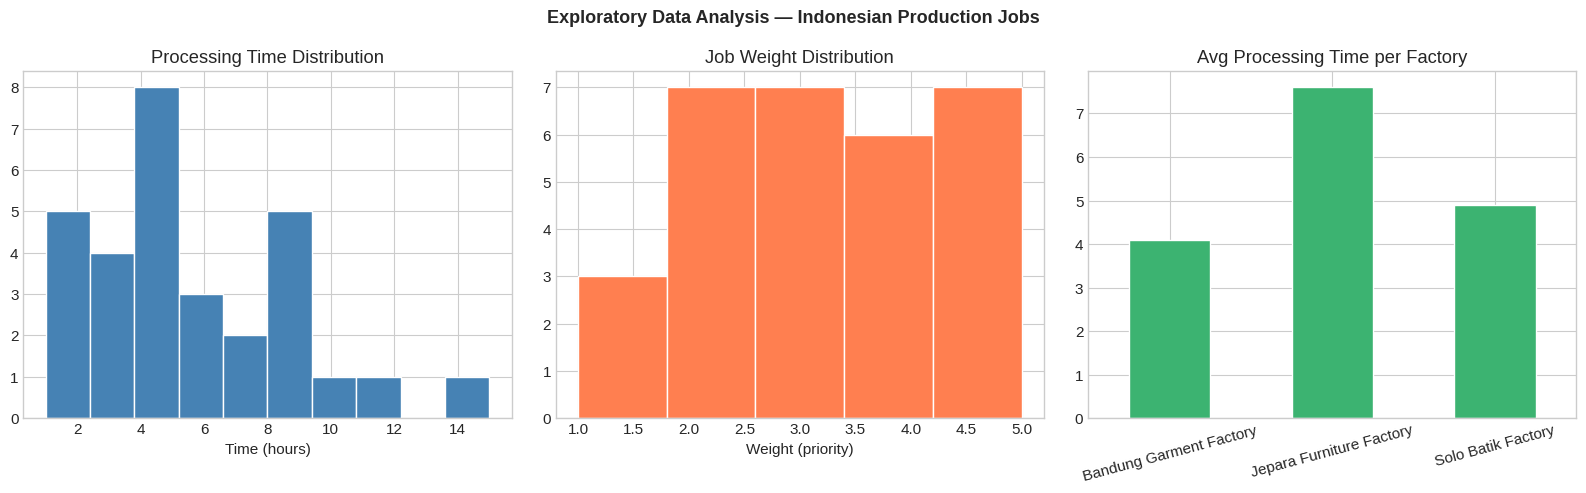

In [ ]:
print('=== DESCRIPTIVE STATISTICS ===')
print(df[['processing_time', 'weight', 'due_date']].describe().round(2))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Exploratory Data Analysis — Indonesian Production Jobs', fontsize=13, fontweight='bold')

df['processing_time'].hist(ax=axes[0], bins=10, color='steelblue', edgecolor='white')
axes[0].set_title('Processing Time Distribution')
axes[0].set_xlabel('Time (hours)')

df['weight'].hist(ax=axes[1], bins=5, color='coral', edgecolor='white')
axes[1].set_title('Job Weight Distribution')
axes[1].set_xlabel('Weight (priority)')

df.groupby('factory')['processing_time'].mean().plot(kind='bar', ax=axes[2], color='mediumseagreen', edgecolor='white')
axes[2].set_title('Avg Processing Time per Factory')
axes[2].set_xlabel('')
axes[2].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('eda.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Scheduling Algorithms

In [ ]:
def calculate_metrics(schedule_df):
    """Compute performance metrics for a given job sequence."""
    df = schedule_df.reset_index(drop=True).copy()
    t = 0
    completion_times = []
    for _, row in df.iterrows():
        t += row['processing_time']
        completion_times.append(t)
    df['completion_time']  = completion_times
    df['tardiness']        = np.maximum(0, df['completion_time'] - df['due_date'])
    df['lateness']         = df['completion_time'] - df['due_date']
    df['weighted_ct']      = df['weight'] * df['completion_time']

    metrics = {
        'Makespan':                   df['completion_time'].max(),
        'Total Completion Time':      df['completion_time'].sum(),
        'Mean Completion Time':       round(df['completion_time'].mean(), 2),
        'Total Weighted Completion':  df['weighted_ct'].sum(),
        'Total Tardiness':            df['tardiness'].sum(),
        'Max Tardiness':              df['tardiness'].max(),
        'Jobs Late':                  int((df['tardiness'] > 0).sum()),
        'Mean Lateness':              round(df['lateness'].mean(), 2)
    }
    return df, metrics

print('Metrics function ready.')

Metrics function ready.


In [ ]:
# === SPT: Shortest Processing Time ===
def spt(df):
    """Sort jobs by shortest processing time first."""
    return df.sort_values('processing_time').reset_index(drop=True)

# === WSPT: Weighted Shortest Processing Time ===
def wspt(df):
    """Sort jobs by processing_time / weight ratio (ascending)."""
    d = df.copy()
    d['ratio'] = d['processing_time'] / d['weight']
    return d.sort_values('ratio').reset_index(drop=True)

# === EDD: Earliest Due Date ===
def edd(df):
    """Sort jobs by earliest due date first."""
    return df.sort_values('due_date').reset_index(drop=True)

# === Johnson's Rule (2-machine flow shop) ===
def johnsons_rule(df, m1='processing_time', m2='weight'):
    """
    Johnson's Rule to minimize makespan in a 2-machine flow shop.
    Machine 2 is represented by the 'weight' column (simulated second machine).
    """
    df = df.copy().reset_index(drop=True)
    remaining = list(df.index)
    first, last = [], []

    while remaining:
        min_t, min_job, min_mach = float('inf'), None, None
        for idx in remaining:
            if df.loc[idx, m1] < min_t:
                min_t, min_job, min_mach = df.loc[idx, m1], idx, 1
            if df.loc[idx, m2] < min_t:
                min_t, min_job, min_mach = df.loc[idx, m2], idx, 2
        remaining.remove(min_job)
        (first if min_mach == 1 else last).insert(0 if min_mach == 2 else len(first), min_job)

    return df.loc[first + last].reset_index(drop=True)

print('All 4 scheduling algorithms ready.')

All 4 scheduling algorithms ready.


## 4. Run All Algorithms

In [ ]:
jobs = df.copy()

spt_sched,  spt_m  = calculate_metrics(spt(jobs))
wspt_sched, wspt_m = calculate_metrics(wspt(jobs))
edd_sched,  edd_m  = calculate_metrics(edd(jobs))
john_sched, john_m = calculate_metrics(johnsons_rule(jobs))

results = pd.DataFrame({
    'SPT':          spt_m,
    'WSPT':         wspt_m,
    'EDD':          edd_m,
    "Johnson's":    john_m
}).T

print('\n=== ALGORITHM COMPARISON RESULTS ===')
print(results.round(2).to_string())


=== ALGORITHM COMPARISON RESULTS ===
           Makespan  Total Completion Time  Mean Completion Time  Total Weighted Completion  Total Tardiness  Max Tardiness  Jobs Late  Mean Lateness
SPT           166.0                 1775.0                 59.17                     6074.0           1381.0          136.0       26.0          45.77
WSPT          166.0                 1986.0                 66.20                     5463.0           1591.0          141.0       28.0          52.80
EDD           166.0                 1785.0                 59.50                     5936.0           1391.0          136.0       26.0          46.10
Johnson's     166.0                 2251.0                 75.03                     5955.0           1857.0          146.0       26.0          61.63


## 5. Gantt Chart Visualization

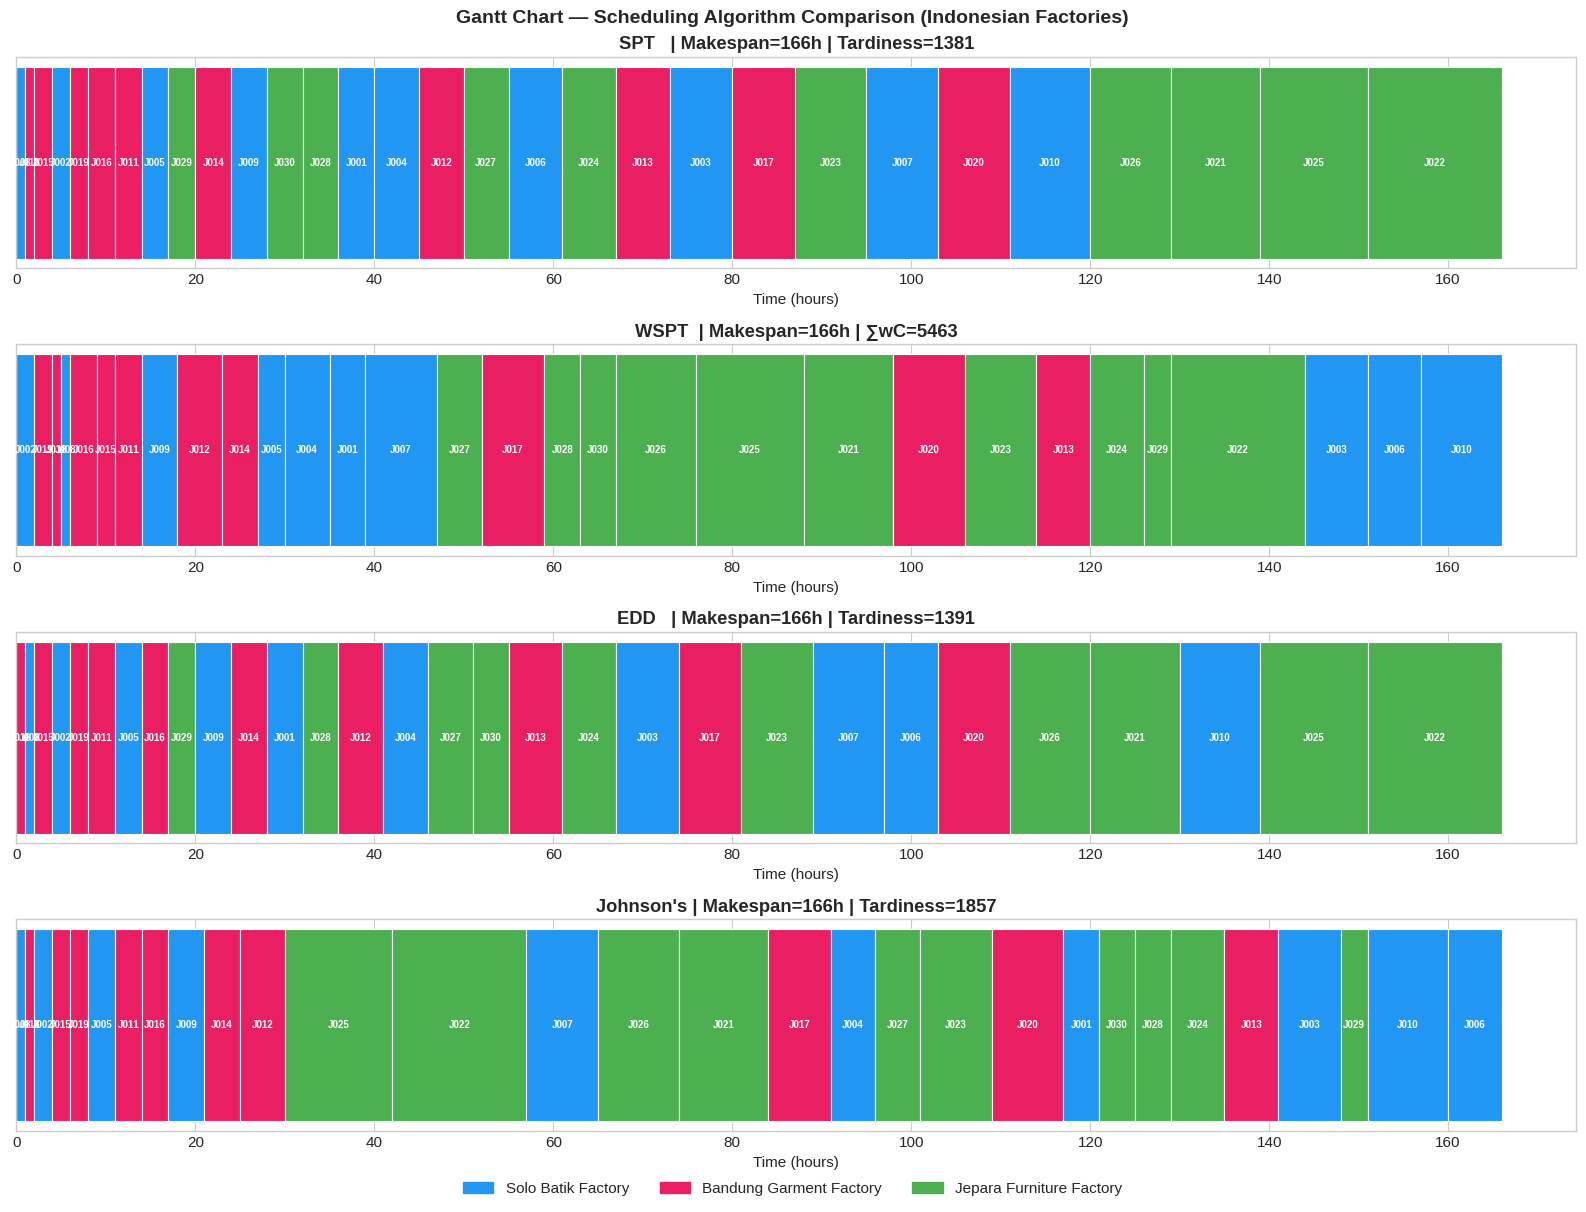

In [ ]:
factory_colors = {
    'Solo Batik Factory':      '#2196F3',
    'Bandung Garment Factory': '#E91E63',
    'Jepara Furniture Factory':'#4CAF50'
}

def plot_gantt(schedule, title, ax):
    t = 0
    for _, row in schedule.iterrows():
        color = factory_colors.get(row['factory'], 'gray')
        ax.barh(0, row['processing_time'], left=t, height=0.5,
                color=color, edgecolor='white', linewidth=0.8)
        ax.text(t + row['processing_time'] / 2, 0,
                row['job_id'], ha='center', va='center', fontsize=7, color='white', fontweight='bold')
        t += row['processing_time']
    ax.set_yticks([])
    ax.set_xlabel('Time (hours)')
    ax.set_title(title, fontweight='bold')

fig, axes = plt.subplots(4, 1, figsize=(16, 12))
fig.suptitle('Gantt Chart — Scheduling Algorithm Comparison (Indonesian Factories)', fontsize=14, fontweight='bold')

plot_gantt(spt_sched,  f'SPT   | Makespan={spt_m["Makespan"]}h | Tardiness={spt_m["Total Tardiness"]:.0f}', axes[0])
plot_gantt(wspt_sched, f'WSPT  | Makespan={wspt_m["Makespan"]}h | ∑wC={wspt_m["Total Weighted Completion"]:.0f}', axes[1])
plot_gantt(edd_sched,  f'EDD   | Makespan={edd_m["Makespan"]}h | Tardiness={edd_m["Total Tardiness"]:.0f}', axes[2])
plot_gantt(john_sched, f"Johnson's | Makespan={john_m['Makespan']}h | Tardiness={john_m['Total Tardiness']:.0f}", axes[3])

legend_patches = [mpatches.Patch(color=c, label=f) for f, c in factory_colors.items()]
fig.legend(handles=legend_patches, loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.02))

plt.tight_layout()
plt.savefig('gantt_chart.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Metric Comparison Charts

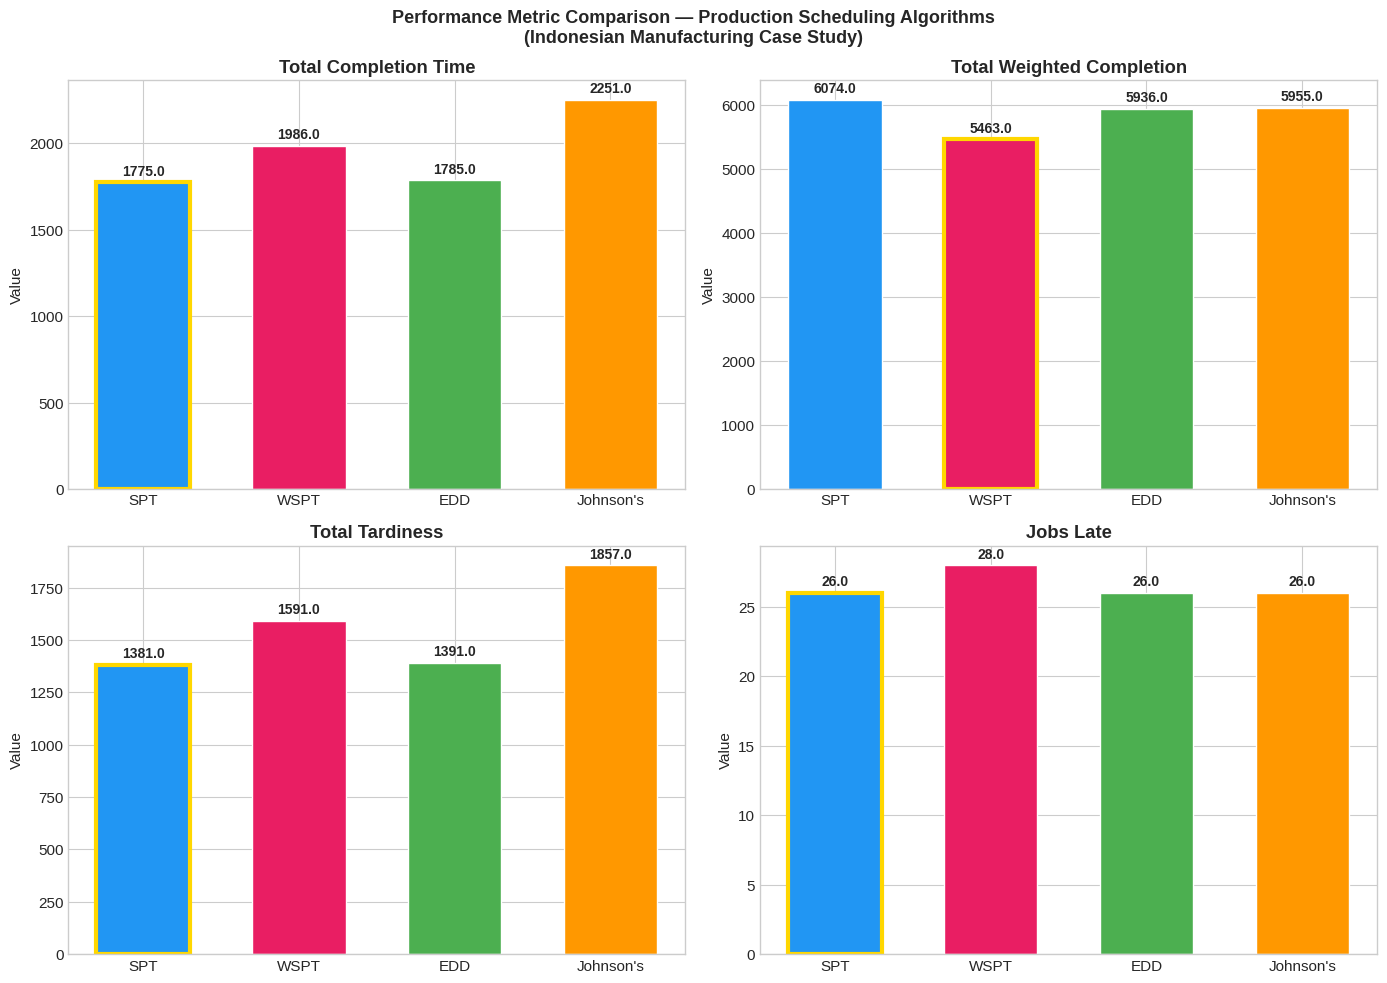

Gold border = best (lowest value) per metric.


In [ ]:
metrics_to_plot = ['Total Completion Time', 'Total Weighted Completion', 'Total Tardiness', 'Jobs Late']
algos   = ['SPT', 'WSPT', 'EDD', "Johnson's"]
palette = ['#2196F3', '#E91E63', '#4CAF50', '#FF9800']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Performance Metric Comparison — Production Scheduling Algorithms\n(Indonesian Manufacturing Case Study)',
             fontsize=13, fontweight='bold')

for ax, metric in zip(axes.flatten(), metrics_to_plot):
    values = [results.loc[a, metric] for a in algos]
    bars = ax.bar(algos, values, color=palette, edgecolor='white', width=0.6)
    ax.set_title(metric, fontweight='bold')
    ax.set_ylabel('Value')
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(values)*0.01,
                f'{val:.1f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    best_idx = int(np.argmin(values))
    bars[best_idx].set_edgecolor('gold')
    bars[best_idx].set_linewidth(3)

plt.tight_layout()
plt.savefig('metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gold border = best (lowest value) per metric.')

## 7. Per-Factory Analysis

=== TARDINESS ANALYSIS BY FACTORY (SPT Schedule) ===
                          total_jobs  avg_processing  total_tardiness  \
factory                                                                 
Bandung Garment Factory           10             4.1              285   
Jepara Furniture Factory          10             7.6              719   
Solo Batik Factory                10             4.9              377   

                          jobs_late  
factory                              
Bandung Garment Factory           8  
Jepara Furniture Factory         10  
Solo Batik Factory                8  


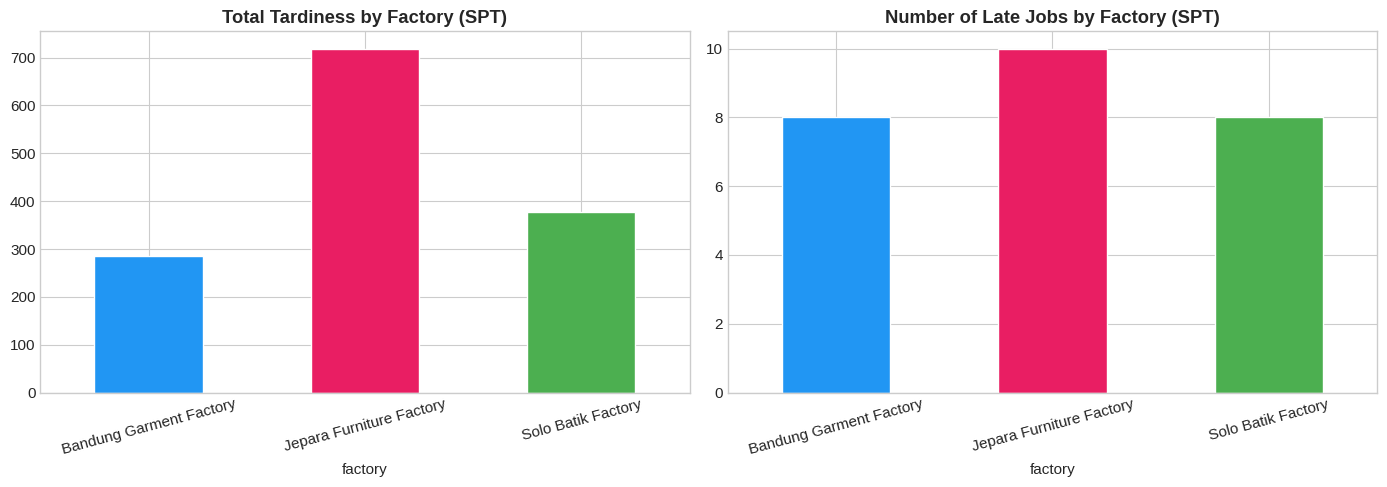

In [ ]:
print('=== TARDINESS ANALYSIS BY FACTORY (SPT Schedule) ===')
factory_analysis = spt_sched.groupby('factory').agg(
    total_jobs      =('job_id', 'count'),
    avg_processing  =('processing_time', 'mean'),
    total_tardiness =('tardiness', 'sum'),
    jobs_late       =('tardiness', lambda x: (x > 0).sum())
).round(2)
print(factory_analysis)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
factory_analysis['total_tardiness'].plot(kind='bar', ax=axes[0],
    color=list(factory_colors.values()), edgecolor='white')
axes[0].set_title('Total Tardiness by Factory (SPT)', fontweight='bold')
axes[0].tick_params(axis='x', rotation=15)

factory_analysis['jobs_late'].plot(kind='bar', ax=axes[1],
    color=list(factory_colors.values()), edgecolor='white')
axes[1].set_title('Number of Late Jobs by Factory (SPT)', fontweight='bold')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('factory_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Conclusion & Recommendations

In [ ]:
print('=' * 65)
print('CONCLUSION — PRODUCTION SCHEDULING ANALYSIS')
print('=' * 65)

print(f'\n Best algorithm to minimize total tardiness        : {results["Total Tardiness"].idxmin()}')
print(f' Best algorithm to minimize weighted completion time: {results["Total Weighted Completion"].idxmin()}')
print(f' Best algorithm to minimize number of late jobs     : {results["Jobs Late"].idxmin()}')

print('\n RECOMMENDATIONS BY BUSINESS OBJECTIVE:')
print('  EDD        → Use when meeting customer deadlines is the top priority')
print('  WSPT       → Use when high-priority jobs (VIP orders) must finish first')
print('  SPT        → Use to maximize throughput (jobs completed per unit time)')
print("  Johnson's  → Use for 2-machine flow shops to achieve minimum makespan")
print('\nAll output charts saved to data/')

CONCLUSION — PRODUCTION SCHEDULING ANALYSIS

 Best algorithm to minimize total tardiness        : SPT
 Best algorithm to minimize weighted completion time: WSPT
 Best algorithm to minimize number of late jobs     : SPT

 RECOMMENDATIONS BY BUSINESS OBJECTIVE:
  EDD        → Use when meeting customer deadlines is the top priority
  WSPT       → Use when high-priority jobs (VIP orders) must finish first
  SPT        → Use to maximize throughput (jobs completed per unit time)
  Johnson's  → Use for 2-machine flow shops to achieve minimum makespan

All output charts saved to data/
